# Girls' Education — Messaging Gap Analysis

This notebook looks at why girls drop out of secondary school in sub-Saharan Africa, and whether NGO communications actually address the reasons families give.

Data sources:
- **World Bank** — girls' secondary enrolment rates (2000–2022)
- **UNICEF** — Out of School Children Study, Sierra Leone 2021
- **NGO corpus** — 20 communications documents (UNICEF Sierra Leone)


In [8]:
import pandas as pd

# Load World Bank girls' secondary enrolment data (rows 1-3 are metadata)
df = pd.read_csv("girls_enrolment.csv", skiprows=4)


## 1. Enrolment trends

Load the World Bank dataset and filter to five countries in West and East Africa where girls' enrolment data is available across 2000–2022.


In [9]:
# Filter to just the countries relevant to the project
countries = ["Nigeria", "Sierra Leone", "Ghana", "Ethiopia", "Mali"]

df_filtered = df[df["Country Name"].isin(countries)]

# Keep only country name and years from 2000 onwards
years = [str(y) for y in range(2000, 2023)]
df_filtered = df_filtered[["Country Name"] + years]

# Reshape so each row is one country-year combination
df_melted = df_filtered.melt(
    id_vars="Country Name",
    var_name="Year",
    value_name="enrolment_pct"
)

# Convert year to integer and drop missing values
df_melted["Year"] = df_melted["Year"].astype(int)
df_melted = df_melted.dropna()


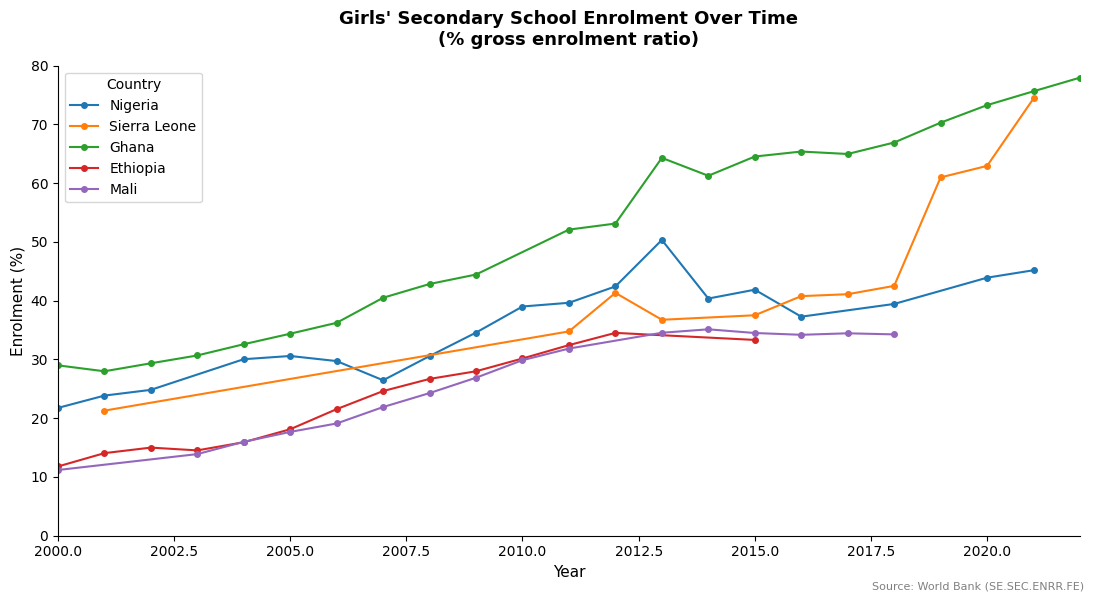

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))

# One line per country
for country in countries:
    country_data = df_melted[df_melted["Country Name"] == country]
    ax.plot(country_data["Year"], country_data["enrolment_pct"],
            marker="o", markersize=4, label=country)

# Labels and formatting
ax.set_title("Girls' Secondary School Enrolment Over Time\n(% gross enrolment ratio)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Enrolment (%)", fontsize=11)
ax.legend(title="Country", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(2000, 2022)
ax.set_ylim(0, 80)

# Add a note about the data source
fig.text(0.99, 0.01, "Source: World Bank (SE.SEC.ENRR.FE)",
         ha="right", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("enrolment_trends.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# Load NGO communications corpus
corpus_df = pd.read_csv("ngo_corpus.csv")
ngo_texts = corpus_df["text"].tolist()


## 2. NGO communications — theme analysis

Load a corpus of 20 NGO documents and score each against six themes using TF-IDF. Unlike raw word counts, TF-IDF down-weights words that appear in every document, so the scores reflect what each document actually emphasises.


In [11]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Themes and their keywords — used to classify NGO communication topics
themes = {
    "Cost / Poverty":      ["cost", "fees", "afford", "money", "poor", "poverty", "financial", "expensive", "bursary", "free"],
    "Marriage / Gender":   ["marriage", "married", "gender", "bride", "husband", "early", "pregnancy", "pregnant", "childbearing"],
    "Safety / Distance":   ["safe", "safety", "distance", "far", "road", "violence", "travel", "remote", "accessible"],
    "Aspiration / Value":  ["future", "opportunity", "empower", "value", "investment", "dream", "potential", "skills", "employment"],
    "Community / Culture": ["community", "culture", "family", "tradition", "norm", "parent", "household", "social"],
    "Enrolment / Targets": ["enrol", "enrollment", "enrolment", "attendance", "rate", "percent", "target", "dropout", "out-of-school"]
}

# Fit TF-IDF across all 20 NGO documents
# min_df=1: include all words; sublinear_tf: dampens very high counts (more robust)
vectorizer = TfidfVectorizer(min_df=1, sublinear_tf=True)
tfidf_matrix = vectorizer.fit_transform(ngo_texts)  # shape: (20 docs × vocab)
vocab = vectorizer.get_feature_names_out()

# For each theme, sum the TF-IDF weights of its keywords across all documents
theme_scores = {}
for theme, keywords in themes.items():
    # Find which vocabulary indices match this theme's keywords
    indices = [i for i, word in enumerate(vocab) if word in keywords]
    if indices:
        # Sum TF-IDF weights for those keywords across all documents
        theme_scores[theme] = tfidf_matrix[:, indices].sum()
    else:
        theme_scores[theme] = 0.0

# Convert to percentages (same format as before — downstream cells unchanged)
ngo_raw = pd.Series(theme_scores)
ngo_series = (ngo_raw / ngo_raw.sum() * 100).round(1)
ngo_series.name = "NGO communications (%)"


In [12]:
# Source: UNICEF Out of School Children Study Sierra Leone 2021
# Table 9: Results of the first priority by gender - Female row
survey_reasons = {
    "Cost / Poverty":      53,   # Money - 53% of females ranked 1st
    "Community / Culture": 14,   # Family - 14%
    "Enrolment / Targets":  8,   # Materials - 8%
    "Safety / Distance":    3,   # Distance - 3%
    "Marriage / Gender":    2,   # Other/Sanitation combined
    "Aspiration / Value":   6,   # Teachers - proxy for value of education
}

survey_series = pd.Series(survey_reasons, name="Families (survey %)")

# Combine into one comparison table
comparison = pd.DataFrame({
    "Families (%)": survey_series,
    "NGOs (%)": ngo_series
})

comparison


,Families (%),NGOs (%)
Aspiration / Value,6,17.0
Community / Culture,14,11.0
Cost / Poverty,53,23.2
Enrolment / Targets,8,13.1
Marriage / Gender,2,26.3
Safety / Distance,3,9.3


## 3. The messaging gap

53% of families in Sierra Leone cite cost and poverty as the #1 reason girls drop out — but only 23% of NGO communications focus on this theme. The table and charts below show the full comparison across all six themes.


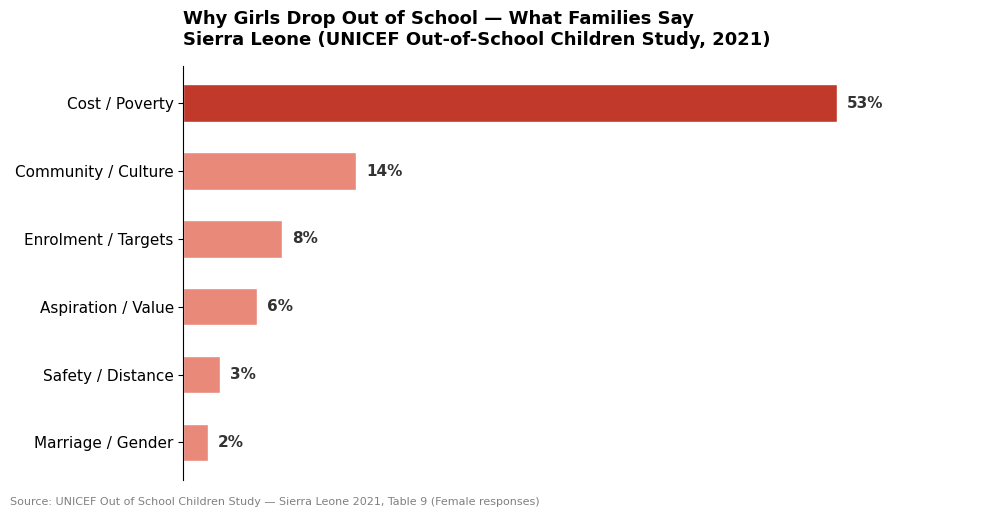

In [7]:
import matplotlib.pyplot as plt

# Data: why families say girls drop out (UNICEF Sierra Leone 2021)
reasons = {
    "Cost / Poverty":      53,
    "Community / Culture": 14,
    "Aspiration / Value":   6,
    "Enrolment / Targets":  8,
    "Safety / Distance":    3,
    "Marriage / Gender":    2,
}

# Sort by value (largest first)
reasons_sorted = dict(sorted(reasons.items(), key=lambda x: x[1], reverse=True))

labels = list(reasons_sorted.keys())
values = list(reasons_sorted.values())

# Colour: highlight the top reason in a strong red, rest in muted coral
bar_colors = ["#C0392B" if v == max(values) else "#E8897A" for v in values]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(labels, values, color=bar_colors, height=0.55, edgecolor="white")

# Add percentage labels at end of each bar
for bar, val in zip(bars, values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f"{val}%", va="center", fontsize=11, fontweight="bold", color="#333333")

# Titles and labels
ax.set_title(
    "Why Girls Drop Out of School — What Families Say\nSierra Leone (UNICEF Out-of-School Children Study, 2021)",
    fontsize=13, fontweight="bold", pad=15, loc="left"
)
ax.set_xlabel("% of families ranking this as the #1 reason", fontsize=10, labelpad=10)
ax.set_xlim(0, 65)
ax.invert_yaxis()  # highest bar at top

# Clean up chart borders
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(axis="y", labelsize=11)

# Source note
fig.text(0.01, -0.02, "Source: UNICEF Out of School Children Study — Sierra Leone 2021, Table 9 (Female responses)",
         fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("family_dropout_reasons.png", dpi=150, bbox_inches="tight")
plt.show()


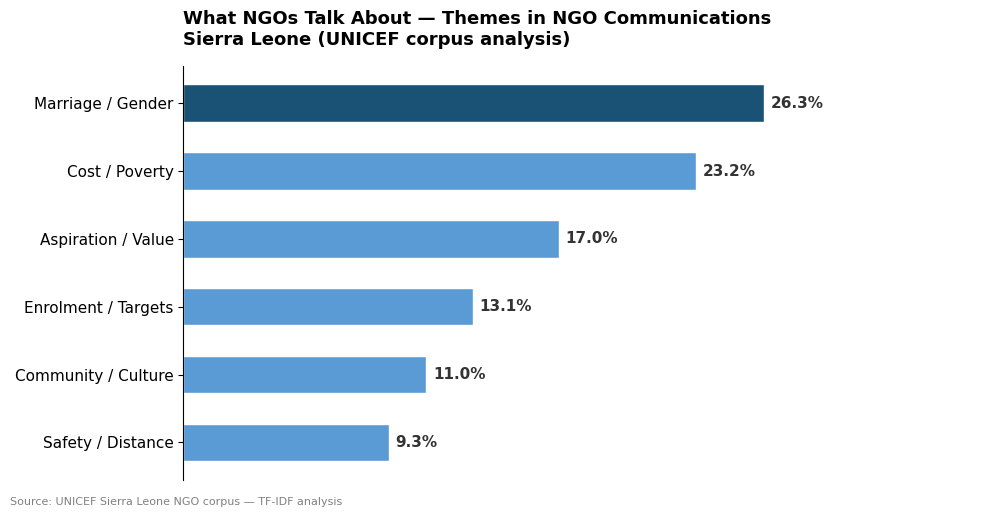

In [8]:
import matplotlib.pyplot as plt

# Sort NGO series by value (largest first)
ngo_sorted = ngo_series.sort_values(ascending=False)

labels = list(ngo_sorted.index)
values = list(ngo_sorted.values)

# Colour: highlight the top theme in deep blue, rest in muted blue
bar_colors = ["#1A5276" if v == max(values) else "#5B9BD5" for v in values]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(labels, values, color=bar_colors, height=0.55, edgecolor="white")

# Add percentage labels at end of each bar
for bar, val in zip(bars, values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val}%", va="center", fontsize=11, fontweight="bold", color="#333333")

# Title
ax.set_title(
    "What NGOs Talk About — Themes in NGO Communications\nSierra Leone (UNICEF corpus analysis)",
    fontsize=13, fontweight="bold", pad=15, loc="left"
)
ax.set_xlim(0, max(values) + 10)
ax.invert_yaxis()  # highest bar at top

# Clean up chart borders
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(axis="y", labelsize=11)

# Source note
fig.text(0.01, -0.02, "Source: UNICEF Sierra Leone NGO corpus — TF-IDF analysis",
         fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("ngo_themes.png", dpi=150, bbox_inches="tight")
plt.show()


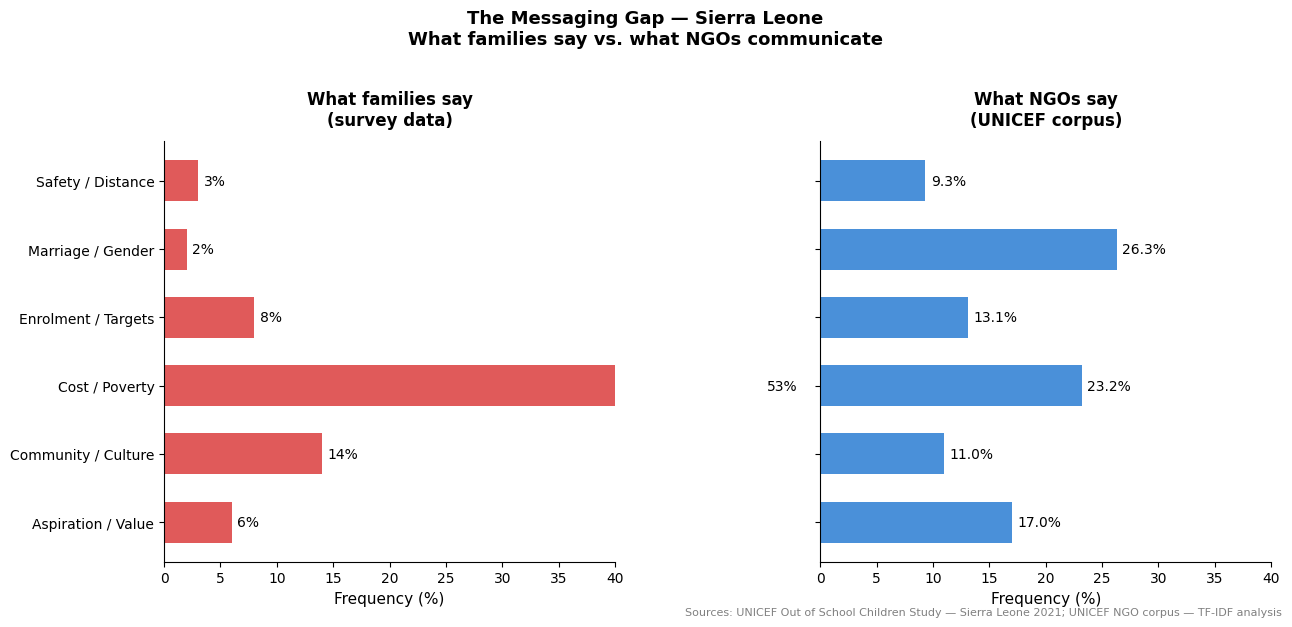

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

colors = ["#E05A5A", "#4A90D9"]
labels = ["What families say\n(survey data)", "What NGOs say\n(UNICEF corpus)"]
data = [comparison["Families (%)"], comparison["NGOs (%)"]]

for ax, values, color, label in zip(axes, data, colors, labels):
    bars = ax.barh(values.index, values.values, color=color, height=0.6)
    ax.set_xlabel("Frequency (%)", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlim(0, 40)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, values.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{val}%", va="center", fontsize=10)

fig.suptitle(
    "The Messaging Gap — Sierra Leone\nWhat families say vs. what NGOs communicate",
    fontsize=13, fontweight="bold", y=1.02
)

fig.text(0.99, 0.01, "Sources: UNICEF Out of School Children Study — Sierra Leone 2021; UNICEF NGO corpus — TF-IDF analysis",
         ha="right", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("messaging_gap.png", dpi=150, bbox_inches="tight")
plt.show()


The chart below shows the gap in percentage points between what families say and what NGOs communicate. Red = families talk about this more than NGOs do. Blue = NGOs talk about this more than families do.


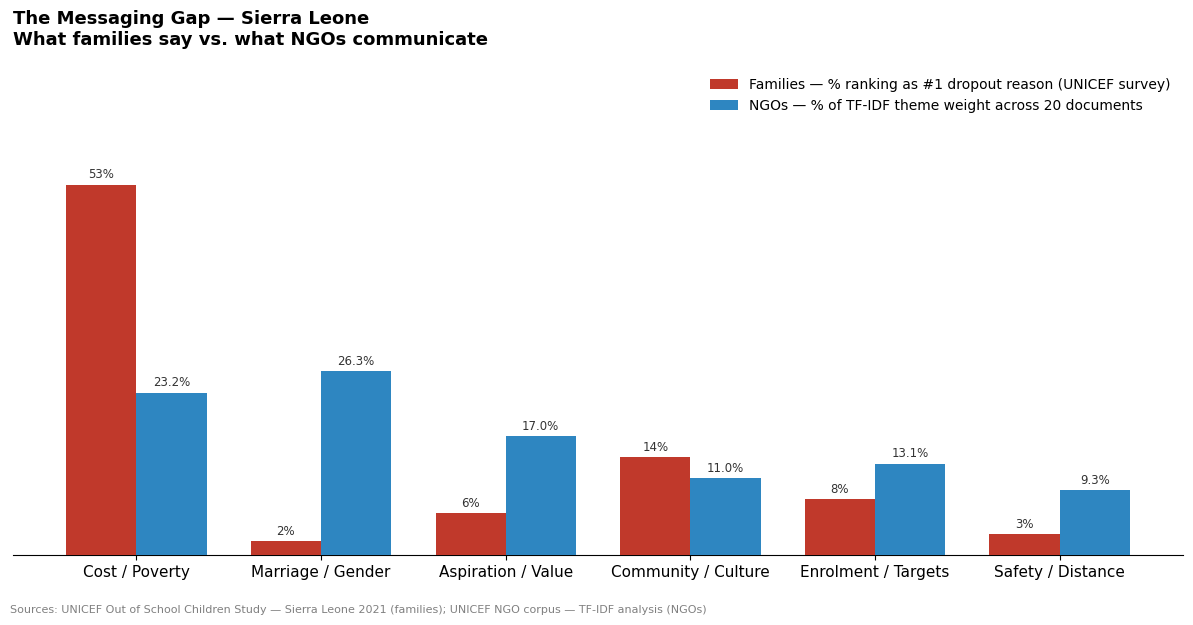

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
themes_order = [
    "Cost / Poverty",
    "Marriage / Gender",
    "Aspiration / Value",
    "Community / Culture",
    "Enrolment / Targets",
    "Safety / Distance",
]

families = [comparison.loc[t, "Families (%)"] for t in themes_order]
ngos     = [round(ngo_series[t], 1) for t in themes_order]

x = np.arange(len(themes_order))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

bars_fam = ax.bar(x - width/2, families, width, label="Families — % ranking as #1 dropout reason (UNICEF survey)",
                  color="#C0392B", zorder=3)
bars_ngo = ax.bar(x + width/2, ngos,     width, label="NGOs — % of TF-IDF theme weight across 20 documents",
                  color="#2E86C1", zorder=3)

# Value labels on bars
for bar in bars_fam:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=8.5, color="#333")
for bar in bars_ngo:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8.5, color="#333")

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(themes_order, fontsize=11)
ax.set_ylabel("")          # values are labelled on bars; legend explains each series
ax.set_ylim(0, 70)
ax.set_title(
    "The Messaging Gap — Sierra Leone\nWhat families say vs. what NGOs communicate",
    fontsize=13, fontweight="bold", pad=15, loc="left"
)
ax.legend(fontsize=10, frameon=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.yaxis.set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)

fig.text(0.01, -0.03,
         "Sources: UNICEF Out of School Children Study — Sierra Leone 2021 (families); UNICEF NGO corpus — TF-IDF analysis (NGOs)",
         fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("messaging_gap_annotated.png", dpi=150, bbox_inches="tight")
plt.show()
